In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
tics_of_trajs = np.load("Ala-lag0.1ps-first5tICs-msmbuild.npy")[:, ::10, :]
print(tics_of_trajs.shape)
chi = (tics_of_trajs).reshape(-1, tics_of_trajs.shape[-1]).T
print(chi.shape)

(100, 10001, 5)
(5, 1000100)


In [3]:
rama_angle = []
with open("ala_rama_all_1ps.txt", "r") as rama_file:
    for line in rama_file:
        rama_angle.append(list(map(float, line.split())))
rama_angle = np.array(rama_angle).T
        
print(rama_angle.shape)

(2, 1000100)


# 343

In [4]:
basis_list = [[[-1.4369482950488706, 2], [0.6657302117358281, 2], [-0.1501981393981321, 2], [5.106734877085593, 2], [0.6502006985050977, 2], [-1.1230678502156788, 2]], [[-1.4369482950488706, 2], [0.6657302117358281, 2], [-0.1501981393981321, 2], [5.106734877085593, 2], [0.6502006985050977, 2], [-1.1230678502156788, 2]], [[-1.4369482950488706, 2], [0.6657302117358281, 2], [-0.1501981393981321, 2], [5.106734877085593, 2], [0.6502006985050977, 2], [-1.1230678502156788, 2]]]
ttica = amuset_tica.AmusetTICA()
svd_v, traj_lens = ttica.build(basis_list, tics_of_trajs)

In [5]:
svd_v_trajs = amuset_tica._convert_to_sequences(svd_v, traj_lens)
print(np.array(svd_v_trajs).shape)

(100, 10001, 343)


In [6]:
bs_v_trajs = np.array(svd_v_trajs)[np.array(range(100))]  # ! caution: neither svd_v_trajs nor bs_v_trajs as a list, not an np-array
bs_svd_v, len_bs_svd_v = amuset_tica._convert_sequences(bs_v_trajs)
print(bs_v_trajs.shape, bs_svd_v.shape) # !
print(len_bs_svd_v)

(100, 10001, 343) (343, 1000100)
[10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001, 10001]


Time = 1 ps
[954.73559     51.6914162   18.9572893    6.04808594   2.17624823
   1.38935405]
Time = 2 ps
[1045.18786697   56.1512062    19.88337646    6.81540417    2.4695812
    2.21292229]
Time = 3 ps
[1078.03711442   57.98500424   20.31272536    5.59235034    2.61673168
    2.36406782]
Time = 4 ps
[1096.16567736   58.94603424   20.43210902    5.88228722    3.43194414
    2.69929222]
Time = 5 ps
[1106.62867676   59.51065699   20.49823717   10.86859945    5.12992908
    3.39339706]
Time = 6 ps
[1113.04790458   59.88157916   20.55881443   15.67606471    7.48798272
    4.7272238 ]
Time = 7 ps
[1117.60253397   60.18587423   51.67234559   20.50645387    7.63846725
    6.03433727]
Time = 8 ps
[1121.09232464   60.45402753   20.39512106   13.11679758    8.0531805
    6.07424542]
Time = 9 ps
[1124.0345982    60.67457298   20.29736598    9.0896281     6.80386155
    5.76141042]
Time = 10 ps
[1126.14689256   60.83865076   20.18534327    9.72028192    9.12719012
    7.87867689]
Time = 11 ps
[112

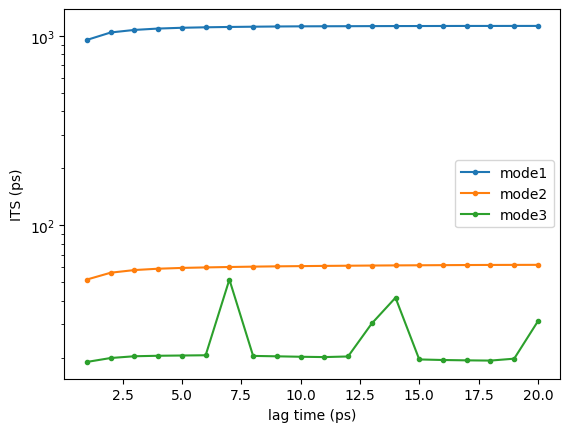

Current date and time: 2026-03-01 11:54:02.522751


In [8]:
ITSs = []
lag_times = list(range(1, 21)) #[2, 4, 6, 8, 10, 20, 30, 40, 50] #[50, 60, 70, 80, 90, 100]
Ks, Es, Vs = [], [], []

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'ps')
    ITSs.append(ttica.timescales_[:6])
    print(ITSs[-1])

Ks343, Es343, Vs343 = Ks, Es, Vs

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(3):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [16]:
ITS343 = ITS.copy()
print("ITS343.shape =", ITS343.shape)

ITS343.shape = (6, 20)


In [9]:
Vt343 = np.load("Ala-343-SVD-Vt.npy")

In [9]:
CV343 = np.matmul(Vs343[2][:, :4].T, Vt343)
CV343[0].min(), CV343[0].max()

(0.0009999500037490608, 0.0009999500037497645)

lag_time = 2


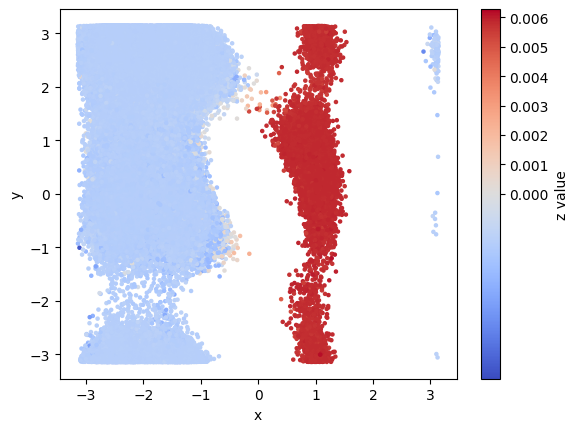

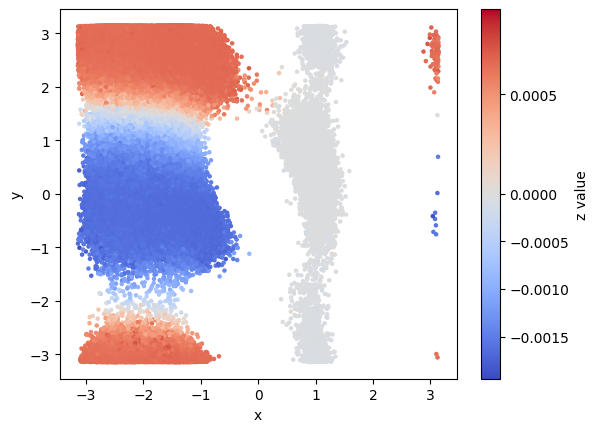

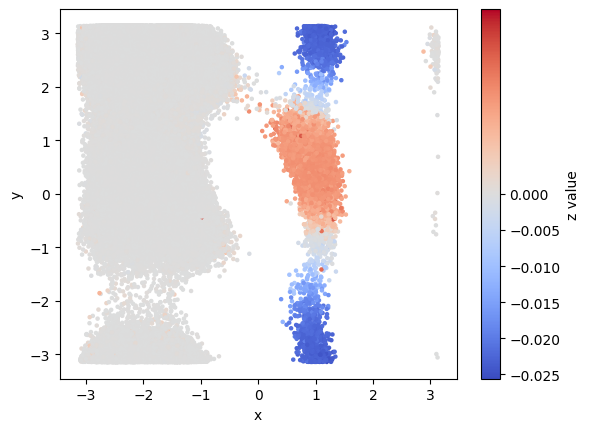

In [10]:
print("lag_time =", lag_times[2])
conver = np.arccos(-1)/180.
for i in range(1, 4): # range(3,4):
    norm = colors.TwoSlopeNorm(vmin=CV343[i].min(), vcenter=np.mean(CV343[i]), vmax=CV343[i].max())
    plt.scatter(rama_angle[0]*conver, rama_angle[1]*conver, c=CV343[i], cmap='coolwarm', s=5, norm=norm)
    plt.colorbar(label='z value')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# 125

['lag_times', 'basis_list', 'Ks']
Time = 1 ps
[438.3582889504308, 51.126284074370076, 17.247833378789757, 2.174837331164556, 1.3852129578240115]
Time = 2 ps
[632.8249955705008, 55.82699472678087, 18.87564336729034, 2.468066734864824, 1.6302134483184751]
Time = 3 ps
[745.3393630357579, 57.749110221837576, 19.632267931837927, 2.6150213912777076, 1.7475848815381185]
Time = 4 ps
[815.8920998378591, 58.76605421602951, 19.898781734866912, 2.696794475420732, 1.8222334702822045]
Time = 5 ps
[866.0060261851557, 59.357215615578156, 20.019020146776757, 2.7538513346110043, 2.025051164922915]
Time = 6 ps
[902.4998770822804, 59.750394447006265, 20.059282096921606, 2.8091409109700853, 2.3852205149380414]
Time = 7 ps
[930.9722831067953, 60.07449054858845, 20.071687585356162, 2.857460705851687, 2.5420337455863065]
Time = 8 ps
[954.1814191079653, 60.3546463634118, 19.964554230536546, 2.9112322644954025, 2.7582496431476478]
Time = 9 ps
[972.0901708761588, 60.58237431516291, 19.875221254917243, 3.31292319

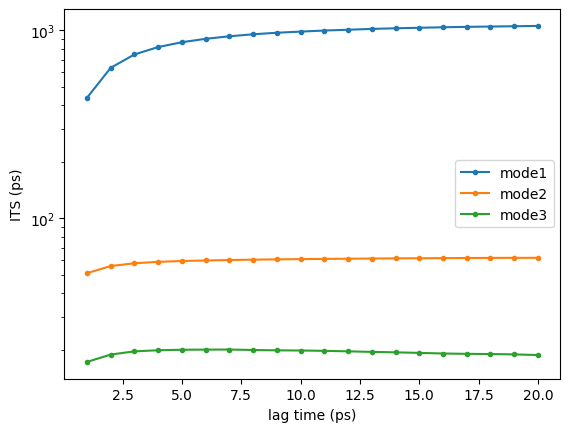

Current date and time: 2026-03-01 11:57:49.559372


In [20]:
loaded_data = np.load("KoopmanMat-2-2-0-mix.npz")
print(loaded_data.files)
lag_times = loaded_data['lag_times']
basis_list = loaded_data['basis_list']
Ks = loaded_data['Ks']

ITSs, Es, Vs = [], [], []
for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    print(ITSs[-1])

Ks125, Es125, Vs125 = Ks, Es, Vs

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(3):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [22]:
ITS125 = ITS.copy()
print("ITS125.shape =", ITS125.shape)
print("ITS343.shape =", ITS343.shape)

ITS125.shape = (5, 20)
ITS343.shape = (6, 20)


# Fitting Functions

In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model



# rank25: tIC 1 & 2

In [5]:
basis_list = [[[-1.4374793412150169, 2], [0.6657108664206016, 2], [-0.14983665789126877, 2], [5.102905128242723, 2]], [[-1.4374793412150169, 2], [0.6657108664206016, 2], [-0.14983665789126877, 2], [5.102905128242723, 2]]]
ttica = amuset_tica.AmusetTICA()
svd_v, traj_lens = ttica.build(basis_list, tics_of_trajs)

Time = 1 ps
[254.10462670607123, 50.471439636826396, 13.30840201414415, 0.8474640990749331, 0.5630386412185615]
Time = 2 ps
[410.8785141399557, 55.37856912410308, 16.117540427651534, 1.0400721681876992, 0.8523703635224036]
Time = 3 ps
[522.444593677073, 57.39671645743043, 17.522347688517325, 1.1423178037908504, 0.9536055946679352]
Time = 4 ps
[602.812360079539, 58.46787028344474, 18.179830838920125, 1.2480525058765384, 1.1682381888857103]
Time = 5 ps
[664.934222398512, 59.107452656932104, 18.580994092287163, 1.6502595907574933, 1.3442665943717755]
Time = 6 ps
[714.0349036243839, 59.53542763013597, 18.75802490767908, 1.8824984476054287, 1.4567795316099323]
Time = 7 ps
[755.5949912766357, 59.88282052289059, 18.891851713428856, 1.6455060387861506, 1.4847466480537828]
Time = 8 ps
[788.0449827119662, 60.181583015764396, 18.884480182631773, 2.224215246330882, 1.9226263415493052]
Time = 9 ps
[816.6752802956524, 60.42119731379174, 18.861467476493207, 2.3417734789302758, 2.1582268528992277]
Tim

NameError: name 'ITS' is not defined

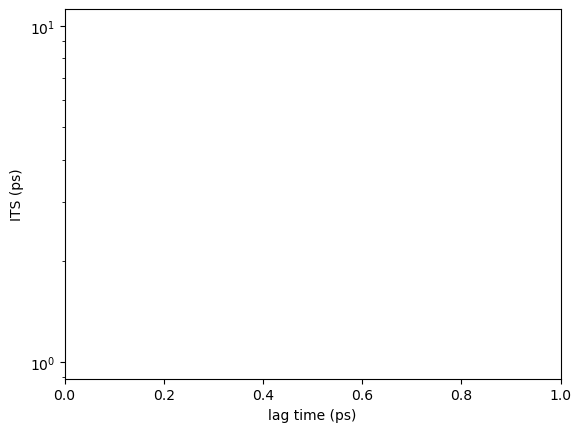

In [6]:
ITSs = []
Ks, Es, Vs = [], [], []
lag_times = list(range(1, 51))

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'ps')
    ITSs.append([-i/np.log(Es[-1][j]) for j in range(1,6)])
    print(ITSs[-1])

Ks25, Es25, Vs25 = Ks, Es, Vs

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

ITS25 = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(3):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [7]:
Ks25 = np.asarray(Ks25)
print(Ks25.shape)
np.save('Ks25.npy', Ks25)

(50, 25, 25)


In [8]:
for i in range(3):#(ITS.shape[0]):
    plt.plot([1/l for l in lag_times[1:]], [1/I for I in ITS[i][1:]], '.-', label='mode'+str(i+1)) 

    plt.legend()
    plt.show()

NameError: name 'ITS' is not defined

## SVD and Ramachadran plots

In [65]:
psi_all = []
for t in range(chi.shape[1]):
    psi_t = [1.0] + [np.exp(- (chi[0][t] - basis_list[0][j][0])**2 / (2 * basis_list[0][j][1]**2))
                     for j in range(len(basis_list[0]))]
    for i in range(1, len(basis_list)):
        phi_temp = [1.0] + [np.exp(- (chi[i][t] - basis_list[i][j][0])**2 / (2 * basis_list[i][j][1]**2))
                     for j in range(len(basis_list[i]))]
        psi_t = np.kron(psi_t, phi_temp)
    psi_all.append(psi_t)
    
Psi = np.stack(psi_all, axis=1)
U, S, Vt = np.linalg.svd(Psi, full_matrices=False)
Vt.shape

(25, 1000100)

In [66]:
CVs_ = np.matmul(Vs[2][:, :4].T, Vt)
CVs_[0].min(), CVs_[0].max()

(0.0009999500037496337, 0.00099995000374999)

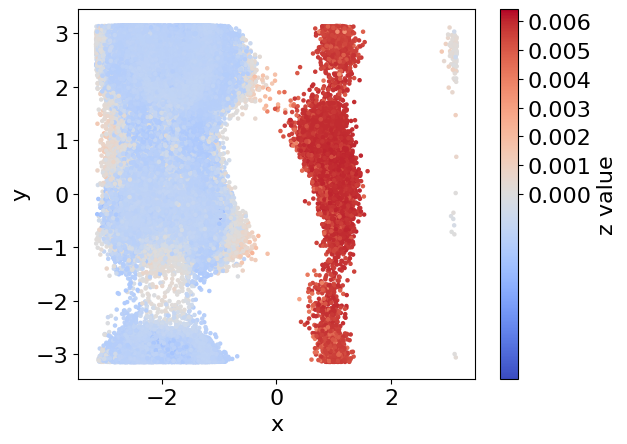

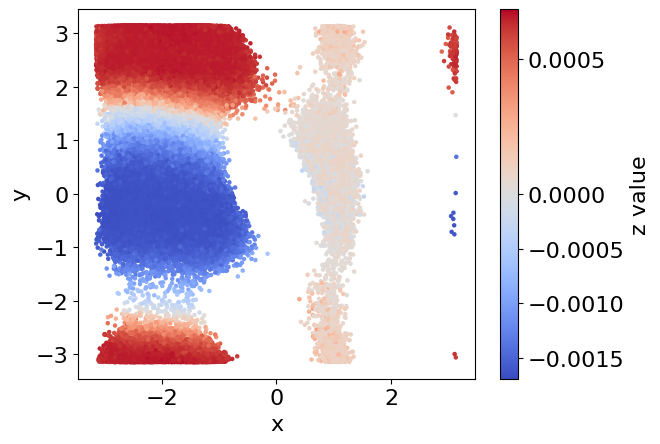

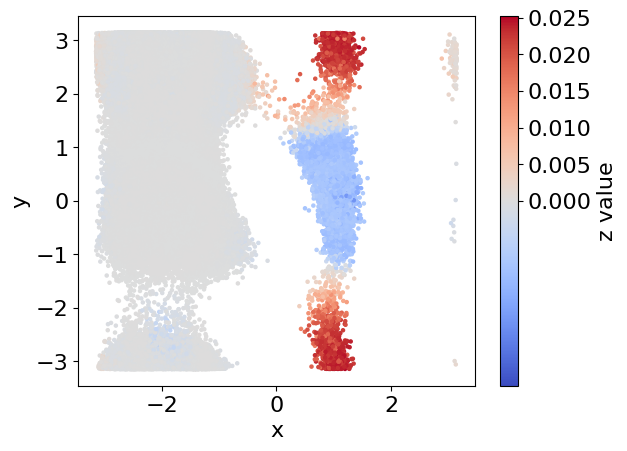

In [67]:
conver = np.arccos(-1)/180.
for i in range(1, 4): # range(3,4):
    norm = colors.TwoSlopeNorm(vmin=CVs_[i].min(), vcenter=np.mean(CVs_[i]), vmax=CVs_[i].max())
    plt.scatter(rama_angle[0]*conver, rama_angle[1]*conver, c=CVs_[i], cmap='coolwarm', s=5, norm=norm)
    plt.colorbar(label='z value')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# 25 (tIC1&2) & 125 & 343

In [69]:
gold_standard = 900

for i in range(3, 10):
    M_hat_25, _ = fit_M_from_K_sequence(Ks25[:i+1], i-3, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_25)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 25')
        break

for i in range(3, 10):
    M_hat_125, _ = fit_M_from_K_sequence(Ks125[:i+1], i-3, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_125)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 125')
        break

for i in range(3, 10):
    M_hat_343, _ = fit_M_from_K_sequence(Ks343[:i+1], i-3, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_343)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 343')
        break


3 (1143.3450328371962-0j)
break 25
3 (1143.5388995552128-0j)
break 125
3 (1151.6096182183237-0j)
break 343


In [73]:
print('ITS25', ITS25[0], '\n', np.where(ITS25[0]>gold_standard)[0][0]+1, 'ps') # +1 as ITS[0]=1ps, ITS[1]=2ps, etc.
print('ITS125', ITS125[0], '\n', np.where(ITS125[0]>gold_standard)[0][0]+1, 'ps')
print('ITS343', ITS343[0], '\n', np.where(ITS343[0]>gold_standard)[0][0]+1, 'ps')

ITS25 [ 254.10462671  410.87851414  522.44459368  602.81236008  664.9342224
  714.03490362  755.59499128  788.04498271  816.6752803   839.43701708
  860.32484586  876.4650241   895.24719935  908.72728342  921.32142042
  932.7271178   942.88770318  950.94297541  958.21133307  967.72270155
  973.50615621  978.2426276   983.61429767  988.38874977  992.64453294
  997.77247717 1001.19265156 1006.28215545 1012.59307332 1017.67485171
 1020.85474403 1025.26731652 1028.36939859 1032.19321539 1035.50874562
 1037.93359765 1040.33840781 1043.41485093 1044.68493868 1048.07086316
 1049.69876365 1052.60258578 1053.66489078 1056.02140477 1057.41628081
 1060.3532253  1061.92748189 1064.67774415 1066.31635242 1068.72606531] 
 14 ps
ITS125 [ 438.35828895  632.82499557  745.33936304  815.89209984  866.00602619
  902.49987708  930.97228311  954.18141911  972.09017088  986.01234134
  998.74185452 1008.63853638 1019.10774786 1026.83685878 1033.18791369
 1039.4973452  1044.87473476 1049.0090623  1052.78851453

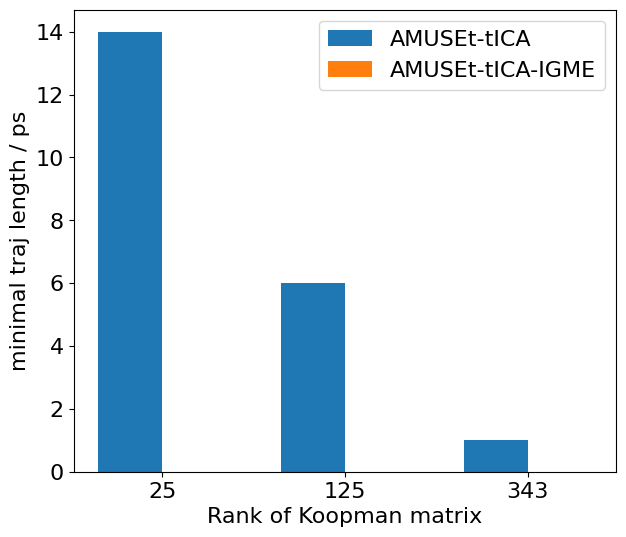

In [74]:
AT_tau_cs = [14, 6, 1]
IGME_tau_cs = [0, 0, 0]

categories = [25, 125, 343]
x = np.arange(len(categories))
width = 0.35

plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7,6))
ax.bar(x - width/2, AT_tau_cs, width, label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("minimal traj length / ps")

plt.legend()
plt.show()

In [75]:
usage_rank = '''AT_tau_cs = [14, 6, 1]
IGME_tau_cs = [0, 0, 0]

categories = [25, 125, 343]
x = np.arange(len(categories))
width = 0.35

plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7,6))
ax.bar(x - width/2, AT_tau_cs, width, label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("minimal traj length / ps")

plt.legend()
plt.show()'''

np.savez('Panel_2b1_savingRank.npz', title='Saving with rank (RAM)', usage = usage_rank)

In [34]:
K_hat_collect = []
categories = [1, 5, 10, 20, 30, 40]
for i in categories:
    M_hat, _ = fit_M_from_K_sequence(Ks25[:i+3], i-1, 1, enforce_hermitian_M=False)
    K_hat_collect.append(M_hat)

ITSs_Khat = []
for i in range(len(K_hat_collect)):
    evK, vrK = np.linalg.eig(K_hat_collect[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    if evK[0] - 1 > 1e-5:
        ITSs_Khat.append([np.abs(-1/np.log(evK[j])) for j in range(2,7)])
    else:
        ITSs_Khat.append([np.abs(-1/np.log(evK[j])) for j in range(1,6)])
    print(ITSs_Khat[-1])#

ITS_Khat = np.array(ITSs_Khat).T
print(ITS_Khat.shape)

[1143.3450328371962, 61.85371827356321, 20.847867361061148, 2.5762257202479333, 2.495275554820048]
[1147.0031020475878, 62.12306486195924, 21.513139246530226, 21.513139246530226, 7.796528415210944]
[1151.8740967649978, 62.569614454740254, 17.91882181948548, 2.2086354787615443, 1.3581653476501525]
[1114.7866288171813, 62.354514918872404, 17.763700236625546, 2.6181716902973, 1.4544868394828003]
[1154.6656836360855, 62.727401295757694, 12.709725285806158, 2.8737596695889605, 2.61977366704722]
[1136.1275763746776, 63.01873859075939, 17.916740296627665, 2.135186462109407, 2.135186462109407]
(5, 6)


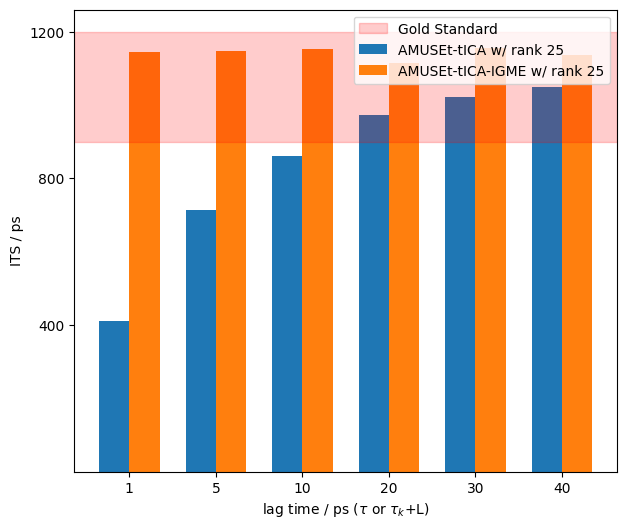

In [35]:
categories = [1, 5, 10, 20, 30, 40]
group1 = ITS25[0][categories]
group2 = ITS_Khat[0]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize = (7,6))
#ax.set_yscale('log')
ax.bar(x - width/2, group1, width, label='AMUSEt-tICA w/ rank 25')
ax.bar(x + width/2, group2, width, label='AMUSEt-tICA-IGME w/ rank 25')
y_min, y_max = 900, 1200
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, categories)
ax.set_xlabel(r"lag time / ps ($\tau$ or $\tau_k$+L)")
ax.set_ylabel("ITS / ps")
#plt.ylim([0, 1300])
plt.yticks([400, 800, 1200])

plt.legend()
plt.show()

In [36]:
combine_data = np.array([categories, group1, group2])
usage_tau = '''x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (8,6))
#ax.set_yscale('log')
ax.bar(x - width/2, data[1], width, label='AMUSEt-tICA w/ rank 25')
ax.bar(x + width/2, data[2], width, label='AMUSEt-tICA-IGME w/ rank 25')
y_min, y_max = 900, 1200
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, data[0])
ax.set_xlabel(r"lag time / ps ($\\tau$ or $\\tau_k$+L)")
ax.set_ylabel("ITS / ps")
#plt.ylim([0, 1300])
plt.yticks([400, 800, 1200])

plt.legend()
plt.show()'''

In [37]:
np.savez('Panel_2b2_savingLagT.npz', title='Saving with lag time', data=combine_data, usage = usage_tau)